In [2]:
import numpy as np
print(np.__version__)

2.4.1


In [ ]:
pip install pandas matplotlib

## 1. 데이터 읽어와서 출력하기
  - `pd.read_csv()`: csv 파일을 읽어와 Pandas Dataframe 으로 반환

In [9]:
import csv
import numpy as np
import pandas as pd

def file_open_by_numpy():
    # np.loadtxt(구분자 = ',', 데이터 타입: string)
    np_arr = np.loadtxt(
        r"C:\Users\SSAFY\Desktop\pjt_02\pjt-02\NFLX.csv",
        delimiter=",",
        encoding="cp949",
        dtype=str
    )
    return np_arr

arr = file_open_by_numpy()
print(arr)

df = pd.DataFrame(arr)
df

[['Date' 'Open' 'High' ... 'Close' 'Adj Close' 'Volume']
 ['2018-02-05' '262.000000' '267.899994' ... '254.259995' '254.259995'
  '11896100']
 ['2018-02-06' '247.699997' '266.700012' ... '265.720001' '265.720001'
  '12595800']
 ...
 ['2022-02-02' '448.250000' '451.980011' ... '429.480011' '429.480011'
  '14346000']
 ['2022-02-03' '421.440002' '429.260010' ... '405.600006' '405.600006'
  '9905200']
 ['2022-02-04' '407.309998' '412.769989' ... '410.170013' '410.170013'
  '7782400']]


,0,1,2,3,4,5,6
0,Date,Open,High,Low,Close,Adj Close,Volume
1,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
3,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
4,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
...,...,...,...,...,...,...,...
1005,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1006,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1007,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1008,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


## 2. 데이터 전처리
  - 요구사항 번호 : F 202
  - Numpy, Pandas 라이브러리 를 활용하여 CSV 파일을 불러온다
  - CSV 구조를 확인하고 필요한 컬럼만 선별한다

In [19]:

# 사용할 컬럼 리스트
use_columns = ['Date', 'Open', 'High', 'Low', 'Close']

# CSV 읽을 때 특정 컬럼만 선택
df = pd.read_csv(file_path, encoding='cp949', usecols=use_columns)

print(df.head())
print(df.shape)  # 행과 열 개수 확인

         Date        Open        High         Low       Close
0  2018-02-05  262.000000  267.899994  250.029999  254.259995
1  2018-02-06  247.699997  266.700012  245.000000  265.720001
2  2018-02-07  266.579987  272.450012  264.329987  264.559998
3  2018-02-08  267.079987  267.619995  250.000000  250.100006
4  2018-02-09  253.850006  255.800003  236.110001  249.470001
(1009, 5)


## 3. 2021년 이후의 데이터 필터링
 - 요구사항 번호 : F 2 0 3
 -  2021 년 이후의 데이터만 필터링한다
 -  필터링 완료된 DataFrame 의 종가 데이터를 그래프로 시각화한다

          Date        Open        High         Low       Close
733 2021-01-04  539.000000  540.799988  515.090027  522.859985
734 2021-01-05  521.549988  526.780029  515.890015  520.799988
735 2021-01-06  511.970001  513.099976  499.500000  500.489990
736 2021-01-07  508.279999  516.440002  506.420013  508.890015
737 2021-01-08  511.309998  513.239990  504.510010  510.399994
(276, 5)


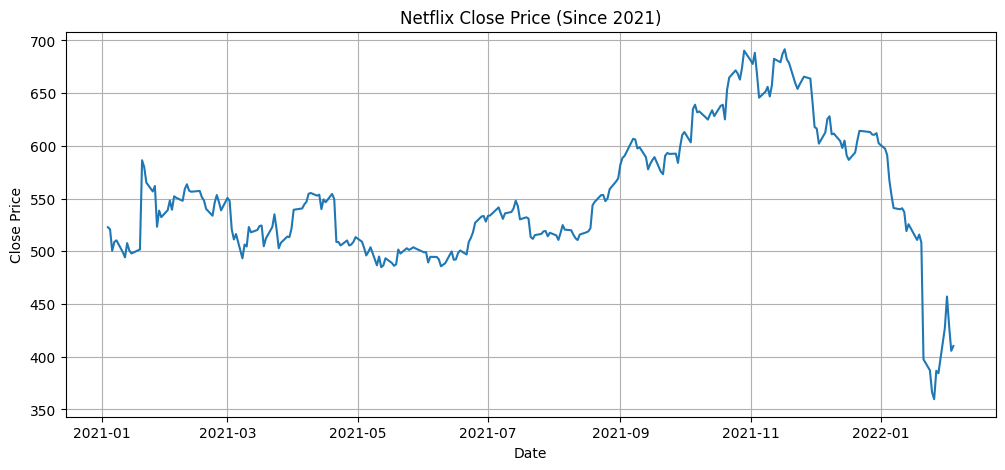

In [20]:
# Date 컬럼을 datetime 타입으로 변환
df['Date'] = pd.to_datetime(df['Date'])

# 2021년 이후 데이터 필터링
df_2021 = df[df['Date'] >= '2021-01-01']

# 필터링 결과 확인
print(df_2021.head())
print(df_2021.shape)

# 종가(Close) 시각화
plt.figure(figsize=(12, 5))
plt.plot(df_2021['Date'], df_2021['Close'])
plt.title('Netflix Close Price (Since 2021)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

## 4. 최고/최저 종가 추출
 - 요구사항 번호 : F 2 0 4
 -  2021 년 이후 데이터에서 종가의 최대 최소 값을 추출한다

In [21]:
# 2021년 이후 데이터 필터링
df_2021 = df[df['Date'] >= '2021-01-01']

# 종가(Close) 최고 / 최저값 추출
max_close = df_2021['Close'].max()
min_close = df_2021['Close'].min()

print(f"2021년 이후 최고 종가: {max_close}")
print(f"2021년 이후 최저 종가: {min_close}")

2021년 이후 최고 종가: 691.690002
2021년 이후 최저 종가: 359.700012


## 5. 월별 평균 종가 계산
 - 요구사항 번호 : F 205
 - 2021 년 이후 데이터를 월별로 그룹화하여 평균 종가 를 계산한다
    계산 결과를 D ataFrame 으로 저장하여 그래프로 시각화한다

     Month       Close
0  2021-01  526.816845
1  2021-02  548.959999
2  2021-03  518.123482
3  2021-04  533.136662
4  2021-05  496.714497


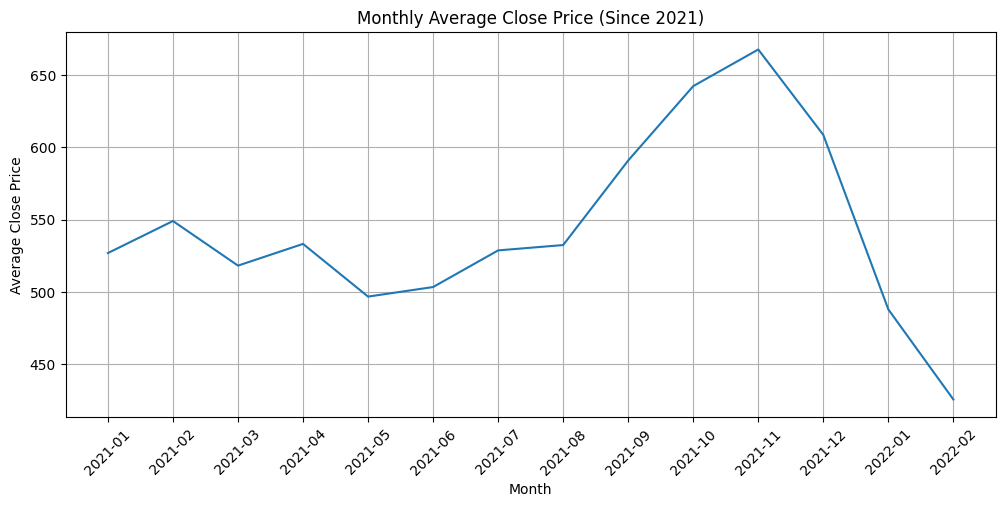

In [22]:
# 월(Month) 컬럼 생성
df_2021['Month'] = df_2021['Date'].dt.to_period('M')

# 월별 평균 종가 계산
monthly_avg = df_2021.groupby('Month')['Close'].mean().reset_index()

print(monthly_avg.head())

# 월별 평균 종가 시각화
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['Month'].astype(str), monthly_avg['Close'])
plt.title('Monthly Average Close Price (Since 2021)')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 6. 월별 최고/ 최저/종가 시각화
 - 요구사항 번호 : F 206
 - 2022 년 이후 의 데이터를 필터링하여 , 월별 최고가 , 최저가 , 종가를 함께 표현하는 복합 라인 그래프를 작성한다

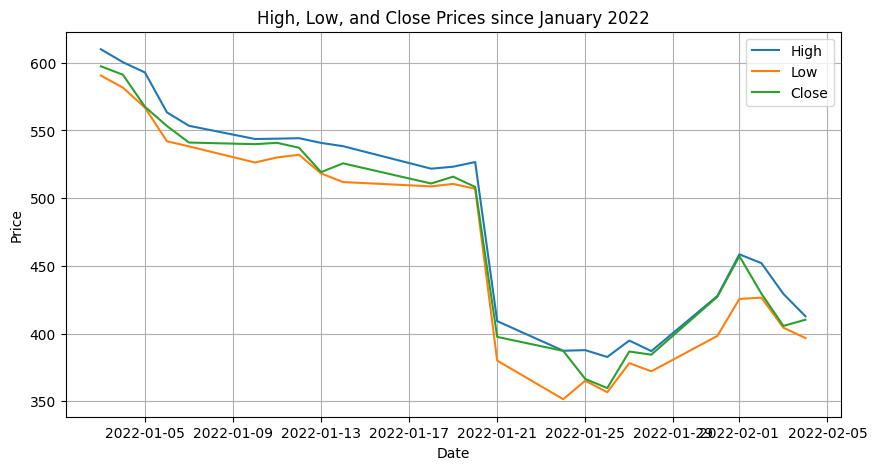

In [23]:
# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(df_2022['Date'], df_2022['High'], label='High')
plt.plot(df_2022['Date'], df_2022['Low'], label='Low')
plt.plot(df_2022['Date'], df_2022['Close'], label='Close')

plt.title('High, Low, and Close Prices since January 2022')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()